This is why long-period planets need stitched data.
Found 66 sectors


Stitched: 2936359 points across 2721 days


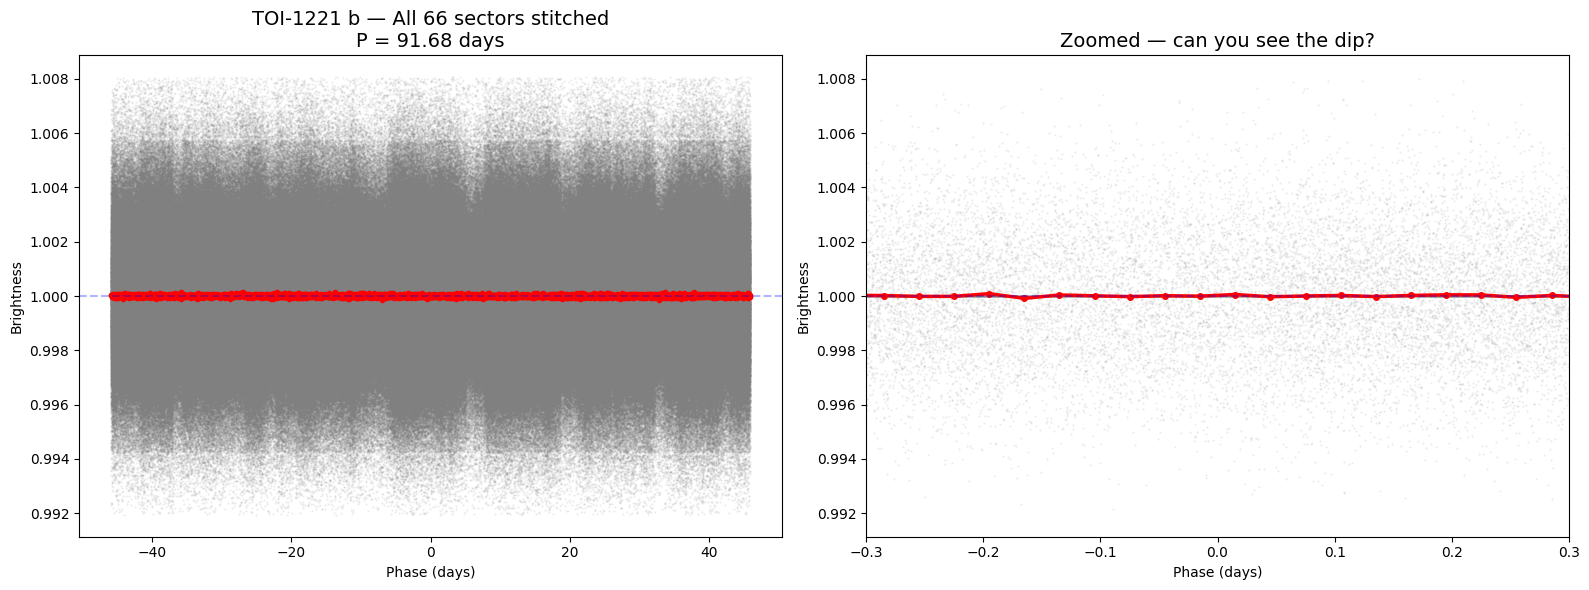


With 66 sectors stitched (2721 days of data),
you have about 29 transits stacked.
Each individual transit is tiny — maybe 200-300 ppm deep.
But stack them all and the signal emerges from the noise.

This planet was invisible in any single sector.
It was found by humans LOOKING at the data, not by BLS.
Then confirmed by stitching sectors 3 + 7 + 10 together.


In [6]:
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# TOI-1221 b — 91.7 day period. Need MULTI-SECTOR data.
print("Downloading ALL sectors for TIC 349095149...")
print("This is why long-period planets need stitched data.")

search = lk.search_lightcurve("TIC 349095149", mission="TESS", author="SPOC")
print(f"Found {len(search)} sectors")

# Download all and stitch
lcs = search.download_all(quality_bitmask='default')
lc = lcs.stitch().flatten(window_length=401).remove_outliers(sigma=4)
print(f"Stitched: {len(lc)} points across {lc.time.value[-1]-lc.time.value[0]:.0f} days")

# Fold at the REAL period (91.68 days)
REAL_PERIOD = 91.68
REAL_T0 = 1544.5

folded = lc.fold(period=REAL_PERIOD, epoch_time=REAL_T0)
binned = folded.bin(time_bin_size=0.03)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full phase
axes[0].scatter(folded.phase.value, folded.flux.value, s=0.5, alpha=0.1, color='gray')
axes[0].plot(binned.phase.value, binned.flux.value, 'o-', color='red', 
             markersize=3, linewidth=2)
axes[0].set_title(f'TOI-1221 b — All {len(search)} sectors stitched\nP = {REAL_PERIOD} days', fontsize=14)
axes[0].set_xlabel('Phase (days)')
axes[0].set_ylabel('Brightness')
axes[0].axhline(1.0, color='blue', linestyle='--', alpha=0.3)

# Zoomed to transit
axes[1].scatter(folded.phase.value, folded.flux.value, s=0.5, alpha=0.1, color='gray')
axes[1].plot(binned.phase.value, binned.flux.value, 'o-', color='red', 
             markersize=4, linewidth=2.5)
axes[1].set_xlim(-0.3, 0.3)
axes[1].set_title('Zoomed — can you see the dip?', fontsize=14)
axes[1].set_xlabel('Phase (days)')
axes[1].set_ylabel('Brightness')
axes[1].axhline(1.0, color='blue', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nWith {len(search)} sectors stitched ({lc.time.value[-1]-lc.time.value[0]:.0f} days of data),")
print(f"you have about {int((lc.time.value[-1]-lc.time.value[0]) / REAL_PERIOD)} transits stacked.")
print(f"Each individual transit is tiny — maybe 200-300 ppm deep.")
print(f"But stack them all and the signal emerges from the noise.")
print(f"\nThis planet was invisible in any single sector.")
print(f"It was found by humans LOOKING at the data, not by BLS.")
print(f"Then confirmed by stitching sectors 3 + 7 + 10 together.")